<a href="https://colab.research.google.com/github/benishshrestha66/Projects/blob/main/School_drop_out_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install any missing packages (openpyxl needed for .xlsx reading)
!pip install -q openpyxl

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns

%matplotlib inline
warnings.filterwarnings('ignore')

print('✅ Imports complete')

✅ Imports complete


In [ ]:
from google.colab import files
uploaded = files.upload()
DATA_FILE = list(uploaded.keys())[0]

Saving Mainn.xlsx to Mainn.xlsx


In [ ]:
C_RED    = '#E63946'
C_ORANGE = '#F4A261'
C_GREEN  = '#2A9D8F'
C_BLUE   = '#457B9D'
C_NAVY   = '#1D3557'
C_GOLD   = '#E9C46A'
C_TEAL   = '#A8DADC'
C_PURPLE = '#6D6875'

GRADE_COLORS = ['#003049','#d62828','#f77f00','#fcbf49','#eae2b7',
                '#2b9348','#55a630','#80b918','#aacc00','#bfd200']
CAUSE_COLORS = [C_RED, C_ORANGE, C_BLUE, C_GREEN, C_GOLD,
                C_TEAL, C_PURPLE, '#b5838d', '#e76f51', '#264653', '#a2d2ff']
ZONE_COLORS  = {'Green': C_GREEN, 'Orange': C_ORANGE, 'Red': C_RED}

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
TITLE_KW = {'fontsize': 15, 'fontweight': 'bold', 'color': C_NAVY}

CAUSE_COLS   = ['Migration','Poverty','Poor_Academics','Child_Marriage',
                'Social_Factors','Distance','Parental_Carelessness',
                'Personal_Beliefs','Teacher_Relationship','Peer_Pressure','Household_Chores']
CAUSE_LABELS = ['Migration','Poverty','Poor Academics','Child Marriage',
                'Social Factors','Distance','Parental Carelessness',
                'Personal Beliefs','Teacher Relationship','Peer Pressure','Household Chores']

print('✅ Colour palette and settings configured')

✅ Colour palette and settings configured


In [ ]:
def load(path=DATA_FILE):
    raw = pd.read_excel(path)
    raw.columns = raw.columns.str.strip()
    df = raw[raw['District Name'] != 'Total'].copy().reset_index(drop=True)

    rename = {
        'Dropout Numbers':                     'Total_Dropouts',
        'Drop out roundoff value':             'Dropout_Rounded',
        'Poverty and family responsibilities': 'Poverty',
        'Poor academic performance':           'Poor_Academics',
        'Child marriage':                      'Child_Marriage',
        'Social factors':                      'Social_Factors',
        'Distance and accessibility':          'Distance',
        'Parental Carelessness':               'Parental_Carelessness',
        'Personal beliefs and interests':      'Personal_Beliefs',
        'Teacher and student relationship':    'Teacher_Relationship',
        'Peer pressure':                       'Peer_Pressure',
        'Household chores':                    'Household_Chores',
    }
    df.rename(columns=rename, inplace=True)

    for g in range(1, 11):
        df[f'DR_G{g}'] = (df[f'G{g} Dropouts'] / df[f'Grade {g}'] * 100).round(2)

    df['Dropout_Rate']   = (df['Total_Dropouts'] / df['Total Students'] * 100).round(2)
    df['Retention_Rate'] = 100 - df['Dropout_Rate']
    df['Attrition_Pct']  = ((df['Grade 1'] - df['Grade 10']) / df['Grade 1'] * 100).round(1)

    def zone(r):
        Q33, Q67 = 2.65, 2.90
        return 'Green' if r < Q33 else ('Orange' if r < Q67 else 'Red')
    df['Risk_Zone'] = df['Dropout_Rate'].apply(zone)

    return df

df = load()

print('=' * 55)
print('  NEPAL DROPOUT CASE STUDY — EDA & VISUALIZATION')
print('=' * 55)
print(f'  Districts      : {len(df)}')
print(f'  Total Students : {int(df["Total Students"].sum()):,}')
print(f'  Total Dropouts : {int(df["Total_Dropouts"].sum()):,}')
print(f'  Avg Dropout %  : {df["Dropout_Rate"].mean():.2f}%')
print(f'  Risk Zones     : {df["Risk_Zone"].value_counts().to_dict()}')
print(f'  Missing values : {df.isnull().sum().sum()}')
df.head()

  NEPAL DROPOUT CASE STUDY — EDA & VISUALIZATION
  Districts      : 75
  Total Students : 1,391,475
  Total Dropouts : 37,227
  Avg Dropout %  : 2.82%
  Risk Zones     : {'Orange': 27, 'Red': 26, 'Green': 22}
  Missing values : 0


,District Name,Grade 1,Grade 2,Grade 3,Grade 4,Grade 5,Grade 6,Grade 7,Grade 8,Grade 9,...,DR_G5,DR_G6,DR_G7,DR_G8,DR_G9,DR_G10,Dropout_Rate,Retention_Rate,Attrition_Pct,Risk_Zone
0,Taplejung,1722,1452,1245,1027,929,589,526,464,320,...,1.5,2.0,2.0,2.5,5.0,32.0,2.72,97.28,85.1,Orange
1,Sankhuwasabha,1022,666,579,512,481,435,311,267,206,...,1.5,2.0,2.0,2.5,5.0,32.0,2.83,97.17,85.5,Orange
2,Solukhumbu,1030,663,548,471,408,376,293,270,162,...,1.5,2.0,2.0,2.5,5.0,32.0,2.57,97.43,90.1,Green
3,Panchthar,1058,622,679,673,530,468,374,331,259,...,1.5,2.0,2.0,2.5,5.0,32.0,3.15,96.85,79.0,Red
4,Ilam,857,658,681,592,585,510,439,500,298,...,1.5,2.0,2.0,2.5,5.0,32.0,3.22,96.78,73.0,Red


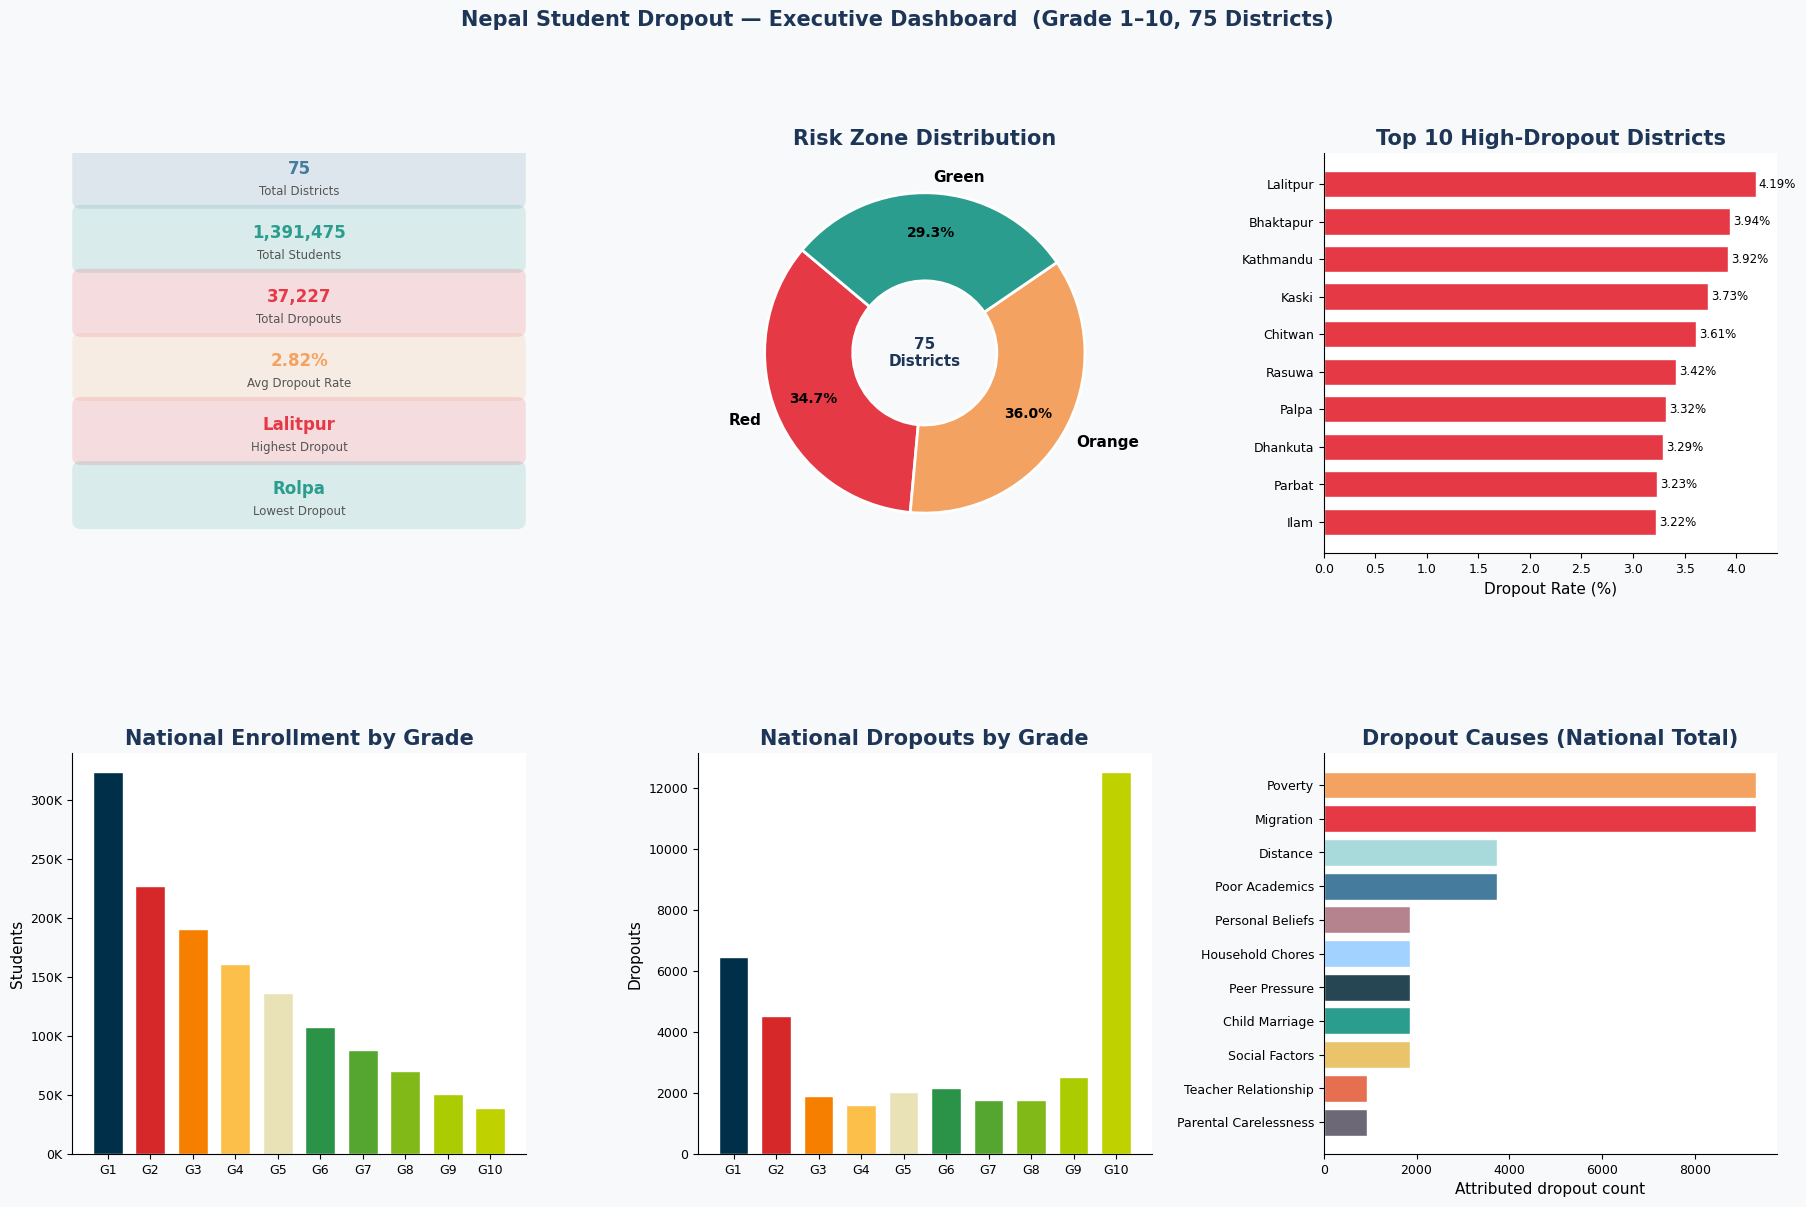

In [ ]:
fig = plt.figure(figsize=(22, 13))
fig.suptitle('Nepal Student Dropout — Executive Dashboard  (Grade 1–10, 75 Districts)',
             **TITLE_KW, y=0.99)
gs = GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0])
ax0.axis('off')
kpis = [
    ('Total Districts',    f'{len(df)}',                     C_BLUE),
    ('Total Students',     f"{int(df['Total Students'].sum()):,}", C_GREEN),
    ('Total Dropouts',     f"{int(df['Total_Dropouts'].sum()):,}", C_RED),
    ('Avg Dropout Rate',   f"{df['Dropout_Rate'].mean():.2f}%",   C_ORANGE),
    ('Highest Dropout',    df.loc[df['Dropout_Rate'].idxmax(),'District Name'], C_RED),
    ('Lowest Dropout',     df.loc[df['Dropout_Rate'].idxmin(),'District Name'], C_GREEN),
]
for i, (lbl, val, col) in enumerate(kpis):
    y = 0.95 - i * 0.16
    ax0.add_patch(mpatches.FancyBboxPatch(
        (0.02, y-0.07), 0.96, 0.13,
        boxstyle='round,pad=0.02', fc=col, ec='none',
        alpha=0.15, transform=ax0.transAxes))
    ax0.text(0.5, y+0.01, val, ha='center', va='center',
             fontsize=12, fontweight='bold', color=col, transform=ax0.transAxes)
    ax0.text(0.5, y-0.045, lbl, ha='center', va='center',
             fontsize=8.5, color='#555', transform=ax0.transAxes)

ax1 = fig.add_subplot(gs[0, 1])
zc = df['Risk_Zone'].value_counts().reindex(['Red','Orange','Green'])
wedge_colors = [ZONE_COLORS[z] for z in zc.index]
wedges, texts, auts = ax1.pie(
    zc, labels=zc.index, autopct='%1.1f%%', colors=wedge_colors,
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11, 'fontweight': 'bold'})
for at in auts: at.set_fontsize(10)
ax1.set_title('Risk Zone Distribution', **TITLE_KW)
ax1.text(0, 0, f'{len(df)}\nDistricts', ha='center', va='center',
         fontsize=11, fontweight='bold', color=C_NAVY)

ax2 = fig.add_subplot(gs[0, 2])
top10 = df.nlargest(10, 'Dropout_Rate')
bar_colors = [ZONE_COLORS[z] for z in top10['Risk_Zone']]
bars = ax2.barh(top10['District Name'], top10['Dropout_Rate'],
                color=bar_colors, edgecolor='white', height=0.7)
ax2.invert_yaxis()
ax2.set_xlabel('Dropout Rate (%)')
ax2.set_title('Top 10 High-Dropout Districts', **TITLE_KW)
for bar, v in zip(bars, top10['Dropout_Rate']):
    ax2.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8.5)

grades = list(range(1, 11))
enroll = [df[f'Grade {g}'].sum() for g in grades]

ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(grades, enroll, color=GRADE_COLORS, edgecolor='white', width=0.7)
ax3.set_xticks(grades)
ax3.set_xticklabels([f'G{g}' for g in grades])
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax3.set_title('National Enrollment by Grade', **TITLE_KW)
ax3.set_ylabel('Students')

drops = [df[f'G{g} Dropouts'].sum() for g in grades]
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(grades, drops, color=GRADE_COLORS, edgecolor='white', width=0.7)
ax4.set_xticks(grades)
ax4.set_xticklabels([f'G{g}' for g in grades])
ax4.set_title('National Dropouts by Grade', **TITLE_KW)
ax4.set_ylabel('Dropouts')

ax5 = fig.add_subplot(gs[1, 2])
ct_sorted = df[CAUSE_COLS].sum().sort_values(ascending=True)
labels_sorted = [CAUSE_LABELS[CAUSE_COLS.index(c)] for c in ct_sorted.index]
ax5.barh(labels_sorted, ct_sorted.values,
         color=[CAUSE_COLORS[CAUSE_COLS.index(c)] for c in ct_sorted.index],
         edgecolor='white')
ax5.set_title('Dropout Causes (National Total)', **TITLE_KW)
ax5.set_xlabel('Attributed dropout count')

plt.show()

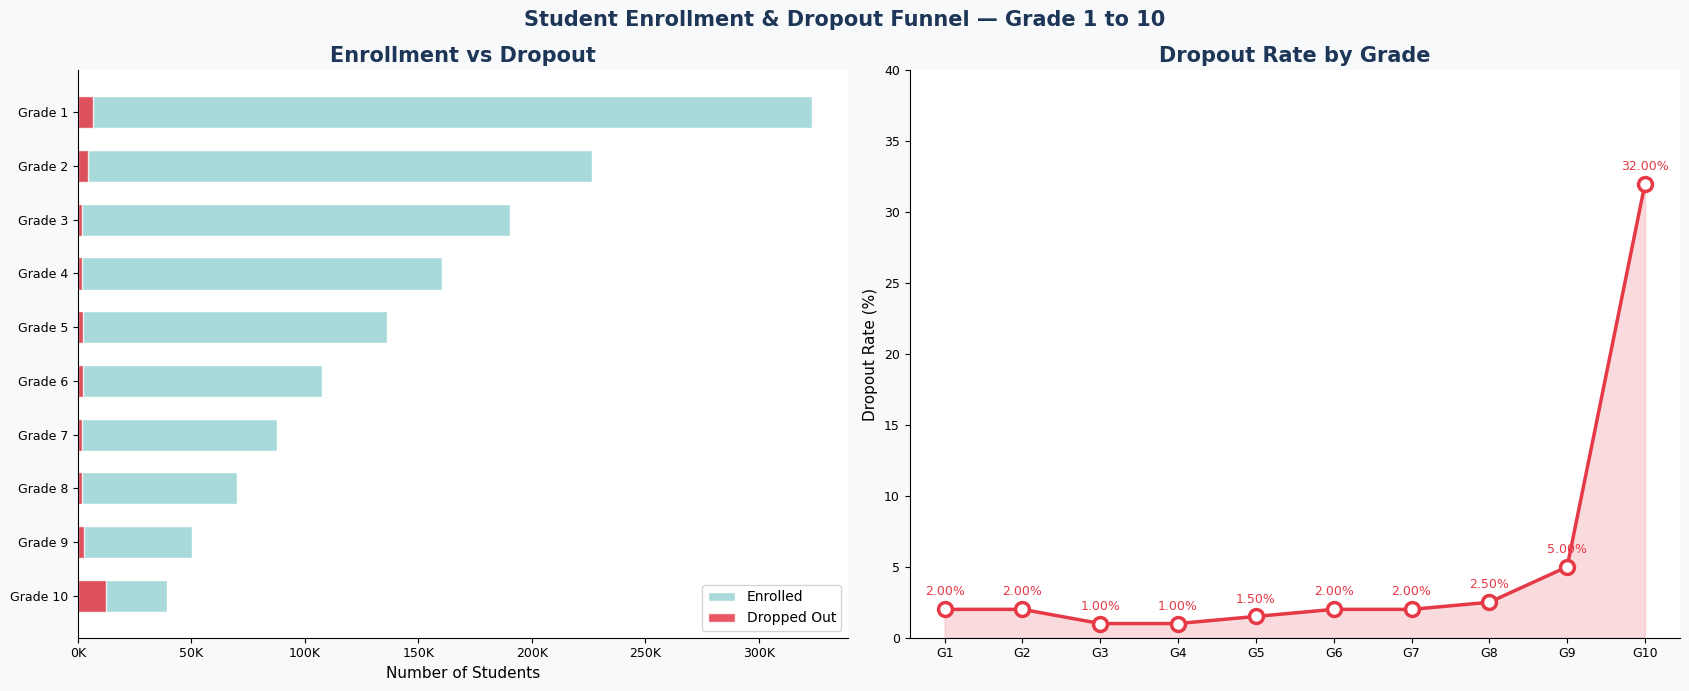

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Student Enrollment & Dropout Funnel — Grade 1 to 10', **TITLE_KW)

grades = list(range(1, 11))
enroll = [df[f'Grade {g}'].sum() for g in grades]
drops  = [df[f'G{g} Dropouts'].sum() for g in grades]
dr_pct = [d/e*100 for d, e in zip(drops, enroll)]

ax = axes[0]
y  = np.arange(len(grades))
ax.barh(y, enroll, color=C_TEAL,  edgecolor='white', label='Enrolled',    height=0.6)
ax.barh(y, drops,  color=C_RED,   edgecolor='white', label='Dropped Out', height=0.6, alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels([f'Grade {g}' for g in grades])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_xlabel('Number of Students'); ax.set_title('Enrollment vs Dropout', **TITLE_KW)
ax.legend(fontsize=10)

ax2 = axes[1]
ax2.fill_between(grades, dr_pct, alpha=0.18, color=C_RED)
ax2.plot(grades, dr_pct, 'o-', color=C_RED, lw=2.5,
         markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for g, r in zip(grades, dr_pct):
    ax2.annotate(f'{r:.2f}%', (g, r), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, color=C_RED)
ax2.set_xticks(grades); ax2.set_xticklabels([f'G{g}' for g in grades])
ax2.set_ylabel('Dropout Rate (%)'); ax2.set_title('Dropout Rate by Grade', **TITLE_KW)
ax2.set_ylim(0, max(dr_pct)*1.25)

plt.tight_layout()
plt.show()

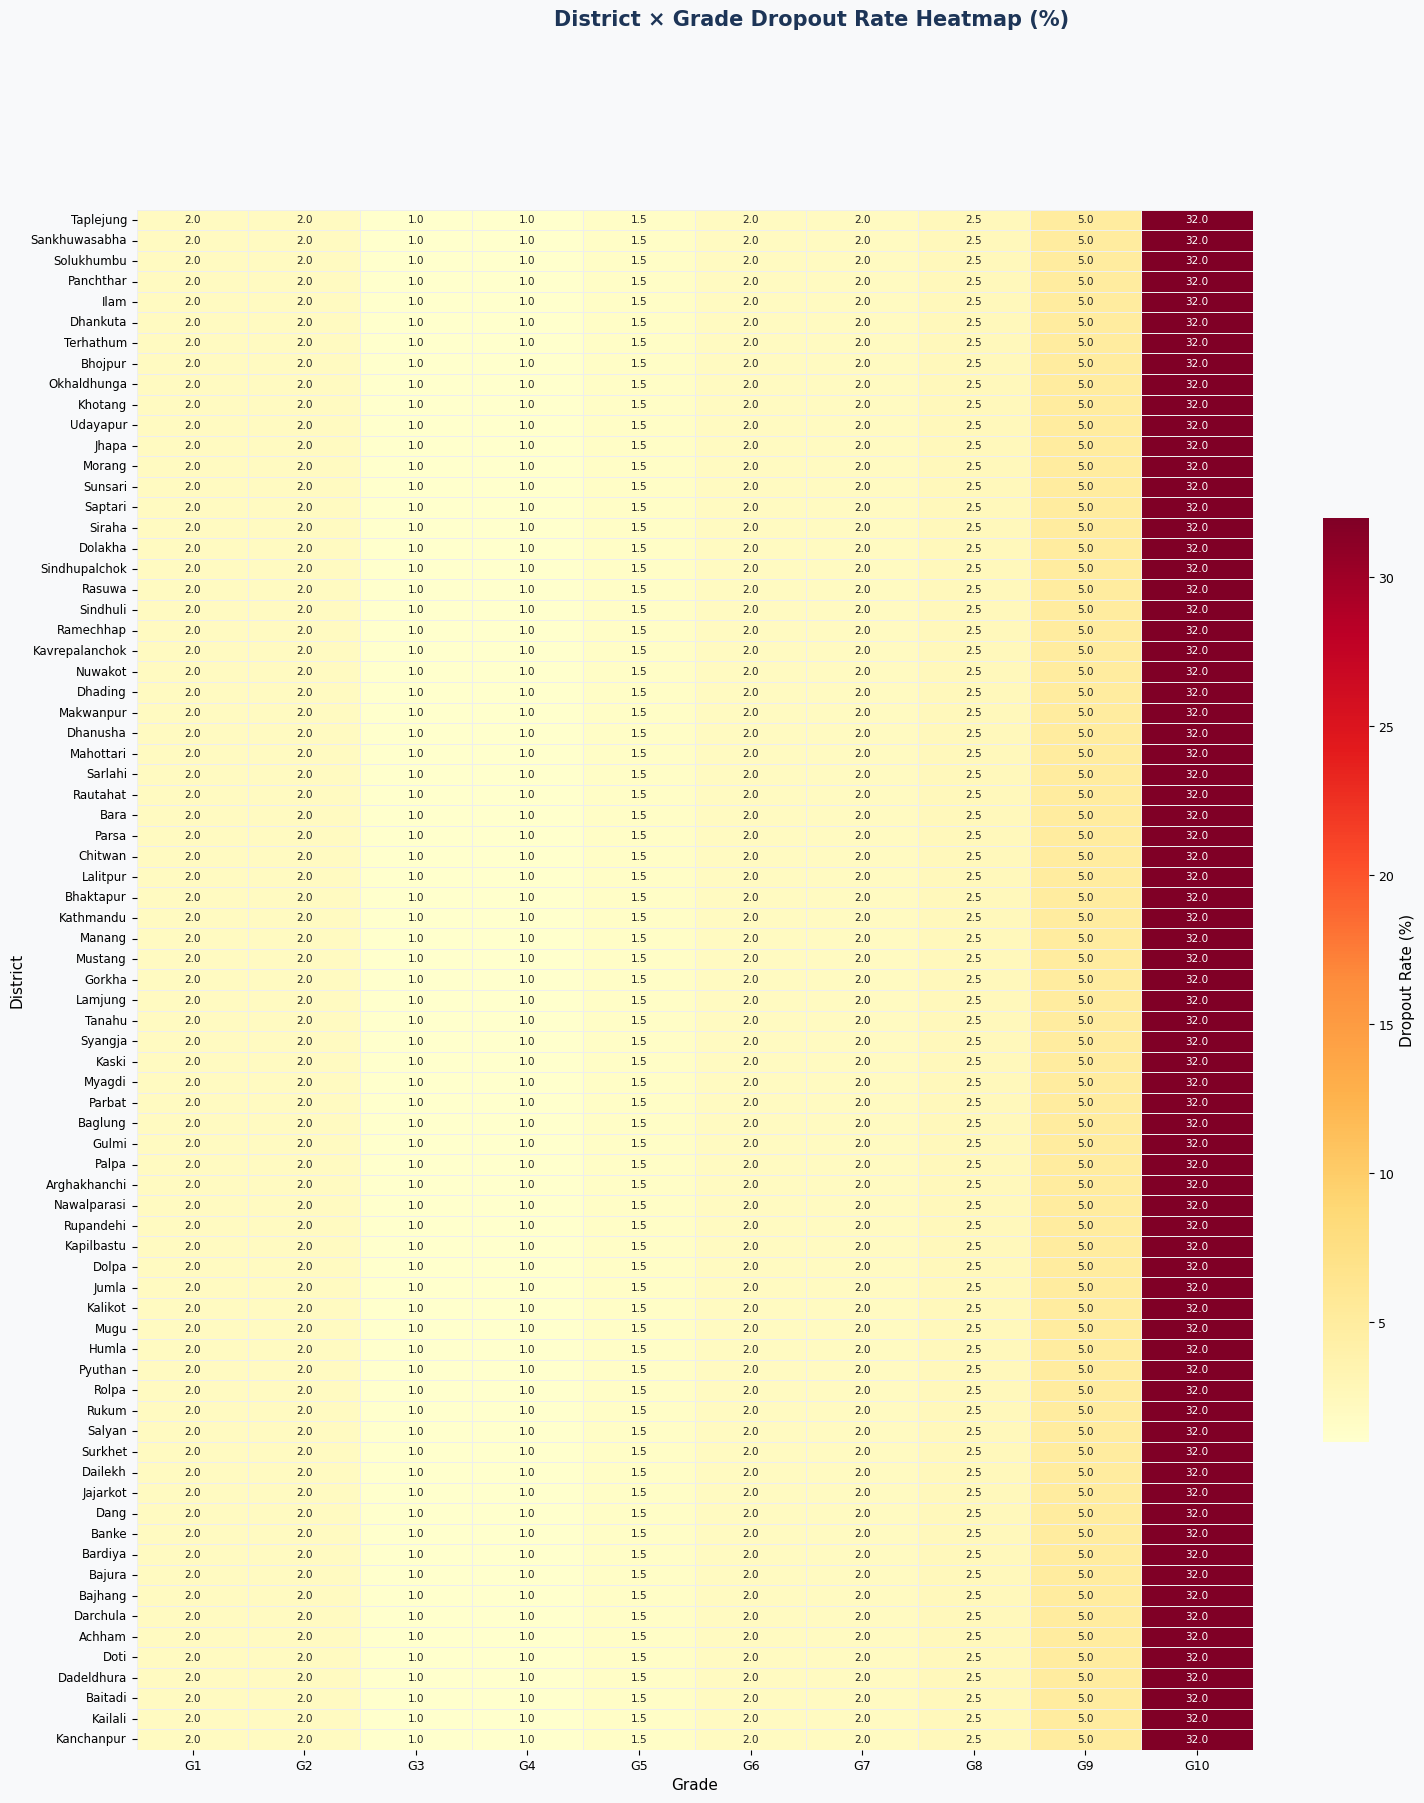

In [ ]:
fig, ax = plt.subplots(figsize=(18, 20))
fig.suptitle('District × Grade Dropout Rate Heatmap (%)', **TITLE_KW)

dr_cols = [f'DR_G{g}' for g in range(1, 11)]
hdf = df.set_index('District Name')[dr_cols]
hdf.columns = [f'G{g}' for g in range(1, 11)]

sns.heatmap(hdf, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='#eee',
            annot_kws={'size': 7.5}, ax=ax,
            cbar_kws={'label': 'Dropout Rate (%)', 'shrink': 0.6})
ax.tick_params(axis='y', labelsize=8.5)
ax.set_xlabel('Grade'); ax.set_ylabel('District')
plt.show()

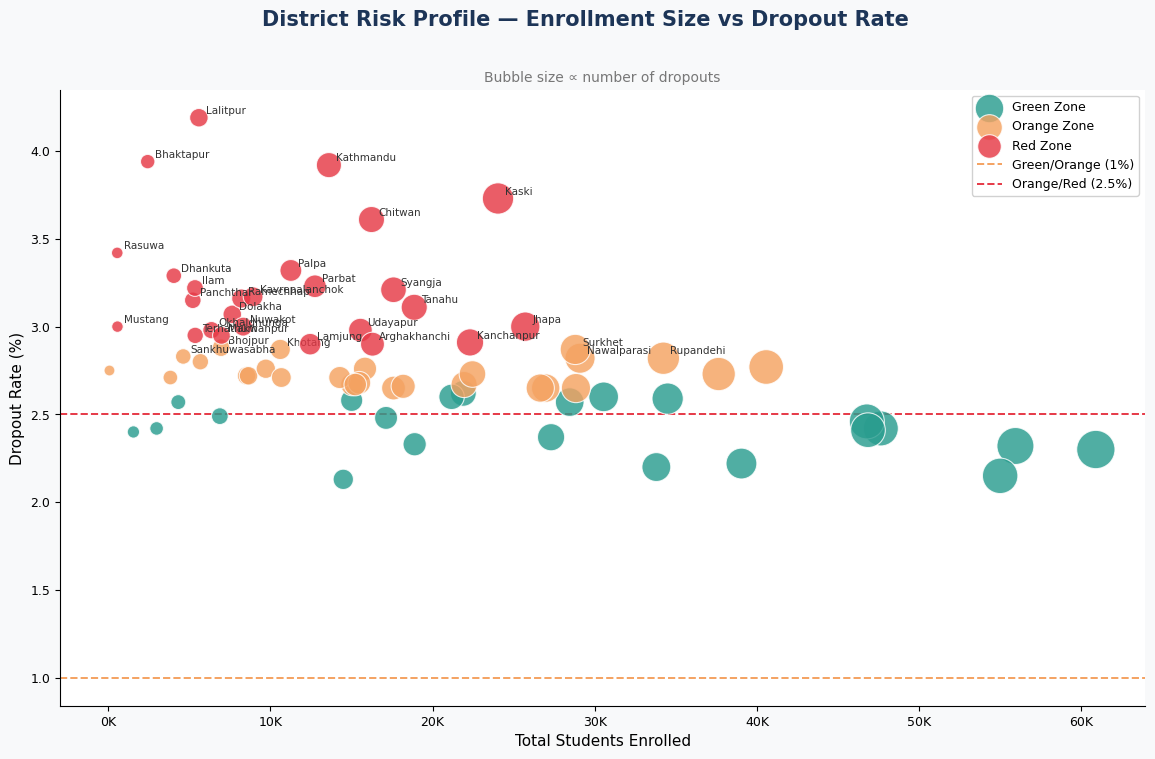

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('District Risk Profile — Enrollment Size vs Dropout Rate', **TITLE_KW)

for zone, col in ZONE_COLORS.items():
    sub = df[df['Risk_Zone'] == zone]
    ax.scatter(sub['Total Students'], sub['Dropout_Rate'],
               c=col, s=sub['Total_Dropouts']/2 + 60,
               alpha=0.82, edgecolors='white', lw=0.8, label=f'{zone} Zone', zorder=3)
    for _, row in sub.iterrows():
        if row['Dropout_Rate'] > 2.8 or row['Total Students'] > 80000:
            ax.annotate(row['District Name'],
                        (row['Total Students'], row['Dropout_Rate']),
                        fontsize=7.5, xytext=(5, 3),
                        textcoords='offset points', color='#333')

ax.axhline(1.0, color=C_ORANGE, ls='--', lw=1.4, label='Green/Orange (1%)')
ax.axhline(2.5, color=C_RED,    ls='--', lw=1.4, label='Orange/Red (2.5%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_xlabel('Total Students Enrolled'); ax.set_ylabel('Dropout Rate (%)')
ax.legend(fontsize=9, framealpha=0.9)
ax.set_title('Bubble size ∝ number of dropouts', fontsize=10, color='#777')
plt.show()

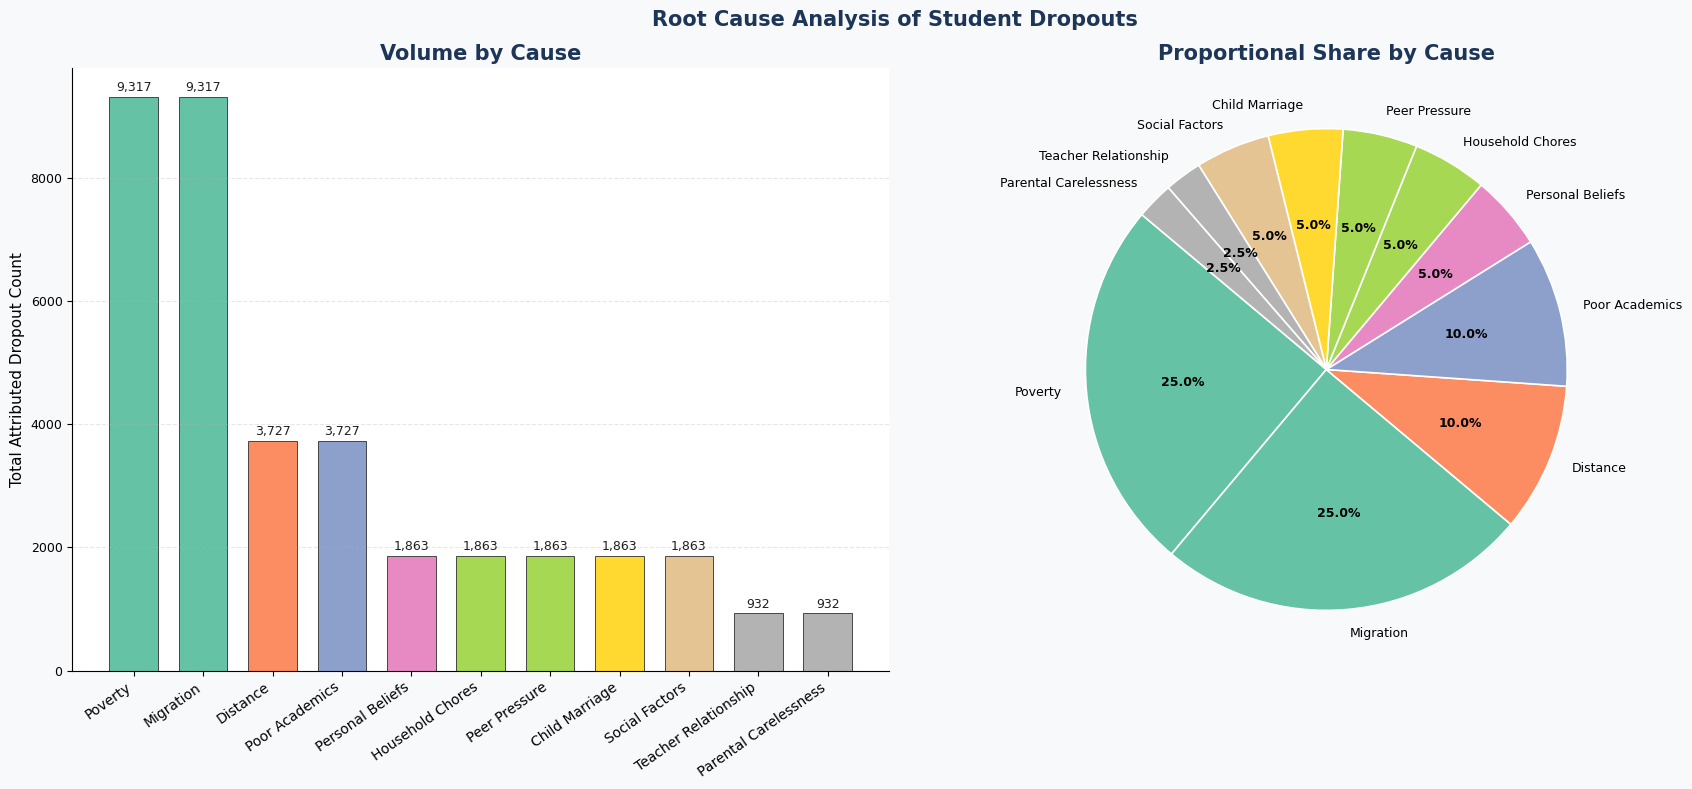

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Root Cause Analysis of Student Dropouts', **TITLE_KW)

# ---- Data preparation ----
totals = df[CAUSE_COLS].sum()
sorted_idx = totals.argsort()[::-1]

s_labels = np.array(CAUSE_LABELS)[sorted_idx]
s_values = totals.values[sorted_idx]

# ✅ Clean professional palette (colorblind-friendly)
palette = plt.cm.Set2(np.linspace(0, 1, len(s_labels)))

# =========================
# BAR CHART (LEFT)
# =========================
ax = axes[0]

bars = ax.bar(
    s_labels,
    s_values,
    color=palette,
    edgecolor='#2f2f2f',   # subtle dark outline (better contrast)
    linewidth=0.6,
    width=0.7
)

ax.set_xticklabels(s_labels, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Total Attributed Dropout Count')
ax.set_title('Volume by Cause', **TITLE_KW)

# cleaner grid (adds readability)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar, v in zip(bars, s_values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(s_values)*0.01,
        f'{v:,.0f}',
        ha='center',
        fontsize=9,
        color='#1f1f1f'
    )

# =========================
# PIE CHART (RIGHT)
# =========================
ax2 = axes[1]

pct = s_values / s_values.sum() * 100

wedges, texts, auts = ax2.pie(
    pct,
    labels=s_labels,
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops={'fontsize': 9}
)

for at in auts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax2.set_title('Proportional Share by Cause', **TITLE_KW)

plt.tight_layout()
plt.show()

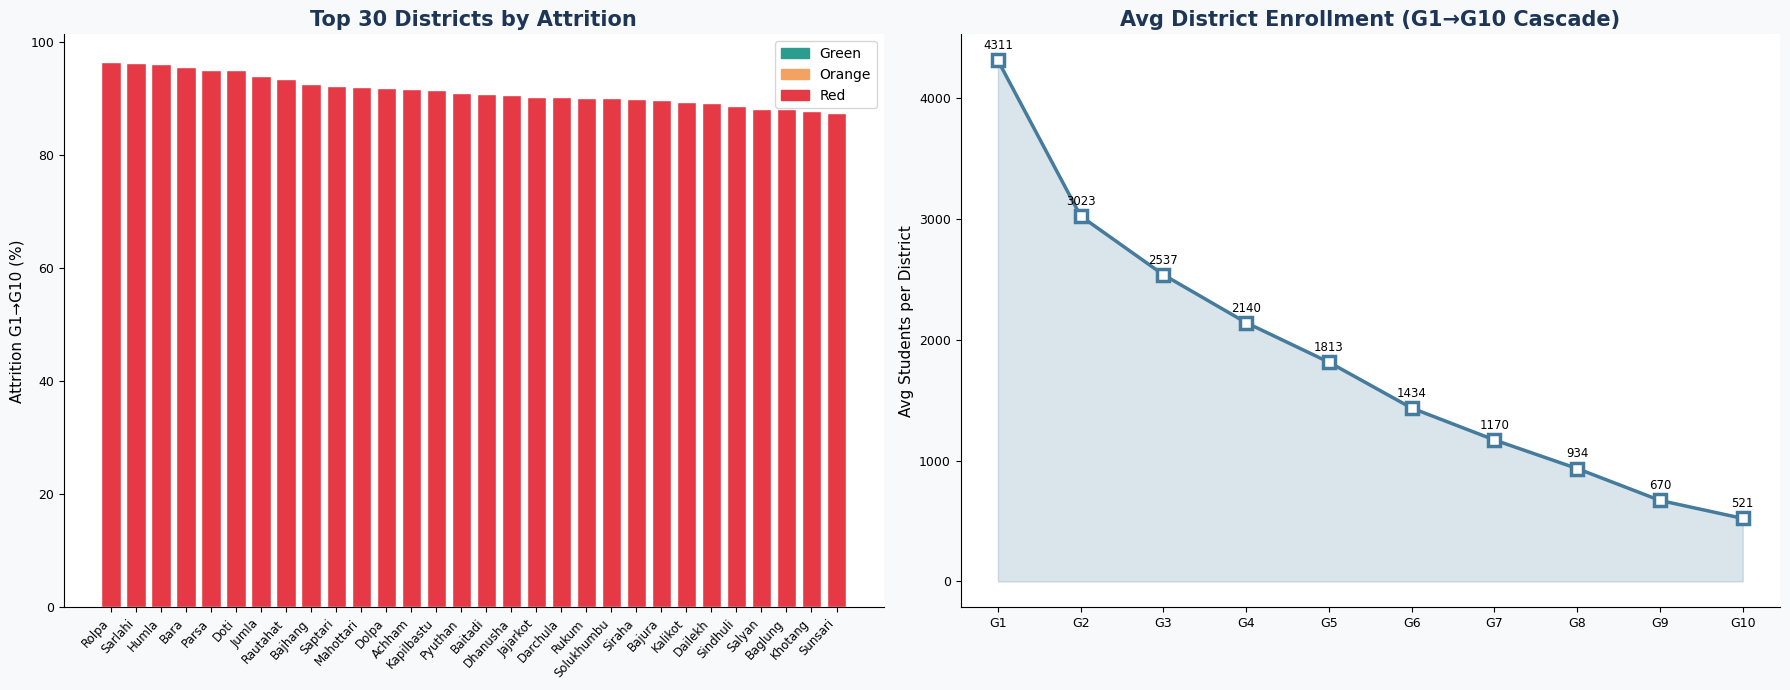

In [ ]:
ig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Grade 1 → Grade 10 Longitudinal Attrition', **TITLE_KW)

df2  = df.sort_values('Attrition_Pct', ascending=False).head(30)
cols = [ZONE_COLORS['Red'] if v>60 else
        ZONE_COLORS['Orange'] if v>40 else
        ZONE_COLORS['Green'] for v in df2['Attrition_Pct']]

axes[0].bar(df2['District Name'], df2['Attrition_Pct'],
            color=cols, edgecolor='white', width=0.78)
axes[0].set_xticklabels(df2['District Name'], rotation=47, ha='right', fontsize=8.5)
axes[0].set_ylabel('Attrition G1→G10 (%)')
axes[0].set_title('Top 30 Districts by Attrition', **TITLE_KW)
patches = [mpatches.Patch(color=v, label=k) for k,v in ZONE_COLORS.items()]
axes[0].legend(handles=patches)

grades = list(range(1, 11))
avg_e  = [df[f'Grade {g}'].mean() for g in grades]
axes[1].fill_between(grades, avg_e, alpha=0.2, color=C_BLUE)
axes[1].plot(grades, avg_e, 's-', color=C_BLUE, lw=2.5,
             markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[1].set_xticks(grades); axes[1].set_xticklabels([f'G{g}' for g in grades])
axes[1].set_title('Avg District Enrollment (G1→G10 Cascade)', **TITLE_KW)
axes[1].set_ylabel('Avg Students per District')
for g, v in zip(grades, avg_e):
    axes[1].annotate(f'{v:.0f}', (g, v), xytext=(0,8),
                     textcoords='offset points', ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

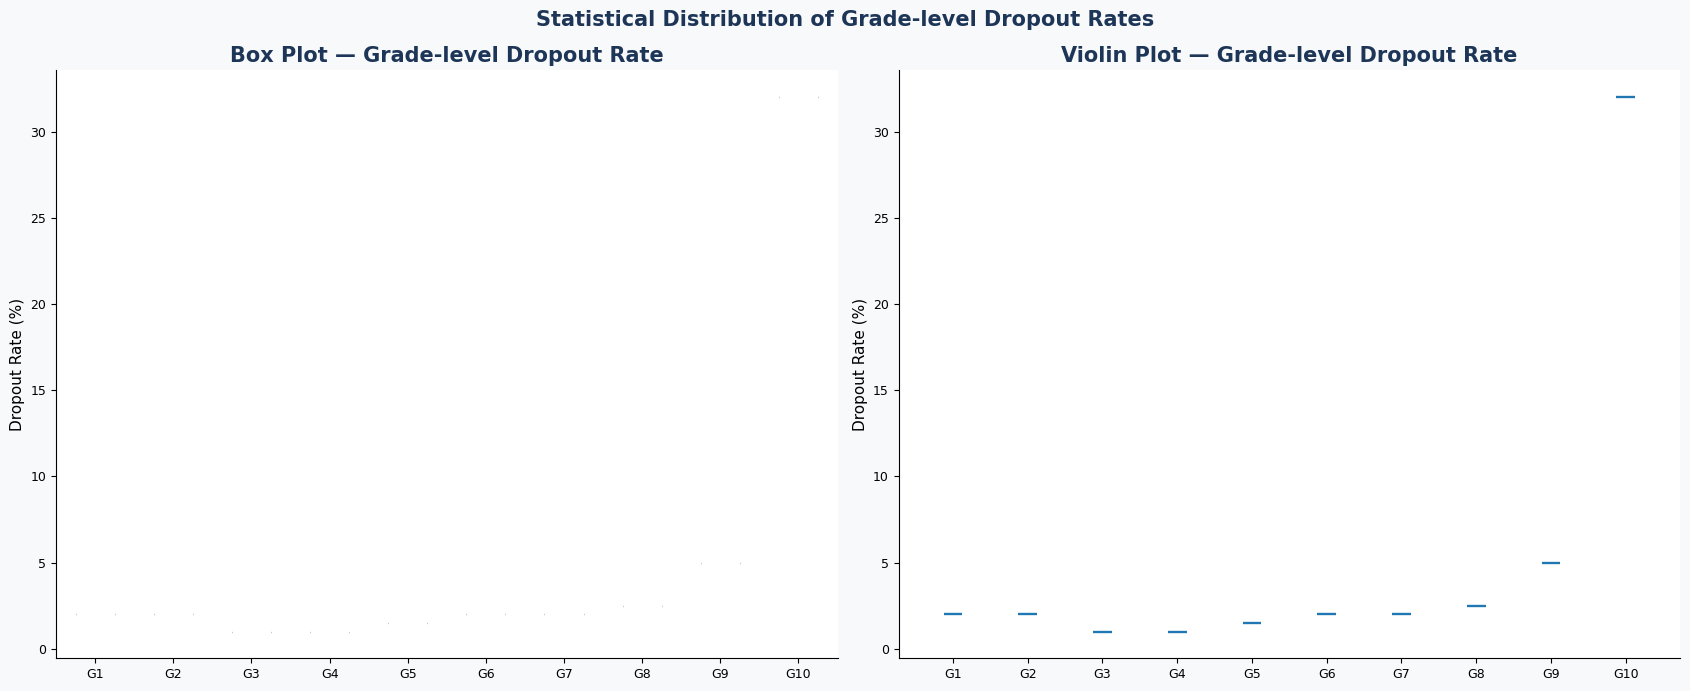

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Statistical Distribution of Grade-level Dropout Rates', **TITLE_KW)

data  = [df[f'DR_G{g}'].dropna().values for g in range(1, 11)]
xlbls = [f'G{g}' for g in range(1, 11)]

bp = axes[0].boxplot(data, patch_artist=True, notch=False,
                     medianprops={'color':'white','lw':2.5},
                     whiskerprops={'color':'#888'},
                     capprops={'color':'#888'})
for patch, col in zip(bp['boxes'], GRADE_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
axes[0].set_xticks(range(1,11)); axes[0].set_xticklabels(xlbls)
axes[0].set_ylabel('Dropout Rate (%)'); axes[0].set_title('Box Plot — Grade-level Dropout Rate', **TITLE_KW)

parts = axes[1].violinplot(data, positions=range(1,11), showmeans=True, showmedians=True)
for pc, col in zip(parts['bodies'], GRADE_COLORS):
    pc.set_facecolor(col); pc.set_alpha(0.75)
axes[1].set_xticks(range(1,11)); axes[1].set_xticklabels(xlbls)
axes[1].set_ylabel('Dropout Rate (%)'); axes[1].set_title('Violin Plot — Grade-level Dropout Rate', **TITLE_KW)

plt.tight_layout()
plt.show()

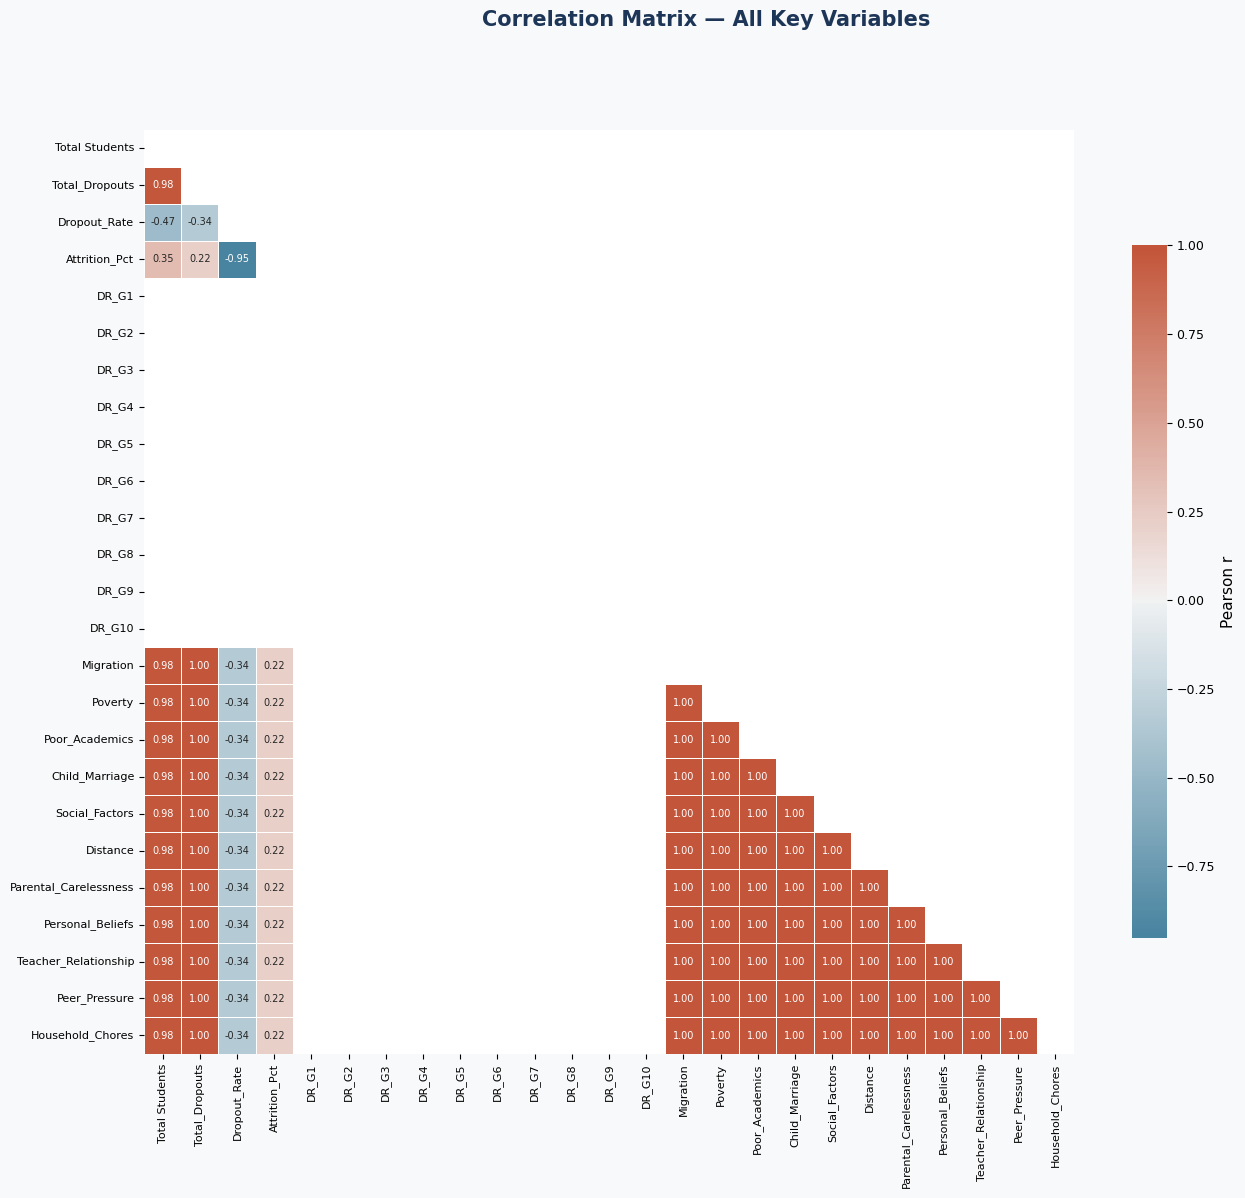

In [ ]:
fig, ax = plt.subplots(figsize=(15, 12))
fig.suptitle('Correlation Matrix — All Key Variables', **TITLE_KW)

num_cols = (['Total Students','Total_Dropouts','Dropout_Rate','Attrition_Pct'] +
            [f'DR_G{g}' for g in range(1,11)] + CAUSE_COLS)
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            cmap=sns.diverging_palette(230, 20, as_cmap=True),
            center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.4,
            ax=ax, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.tick_params(labelsize=8)
plt.show()

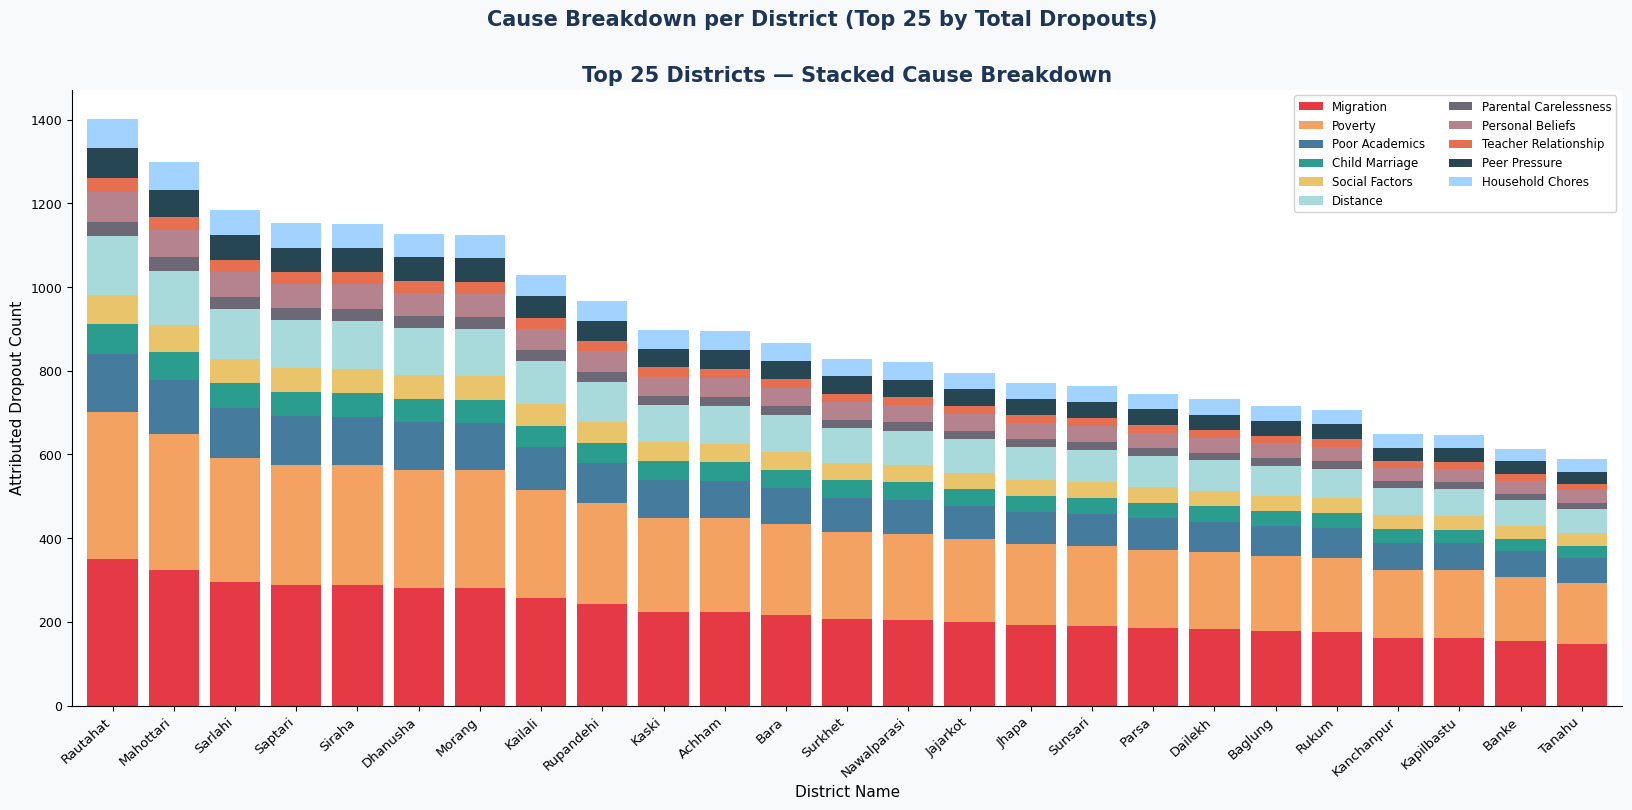

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
fig.suptitle('Cause Breakdown per District (Top 25 by Total Dropouts)', **TITLE_KW)

top25 = df.nlargest(25, 'Total_Dropouts').set_index('District Name')
cause_df = top25[CAUSE_COLS].copy()
cause_df.columns = CAUSE_LABELS
cause_df.plot(kind='bar', stacked=True, ax=ax,
              color=CAUSE_COLORS, edgecolor='none', width=0.82)
ax.set_xticklabels(top25.index, rotation=42, ha='right', fontsize=9.5)
ax.set_ylabel('Attributed Dropout Count')
ax.legend(loc='upper right', fontsize=8.5, ncol=2, framealpha=0.85)
ax.set_title('Top 25 Districts — Stacked Cause Breakdown', **TITLE_KW)
plt.show()

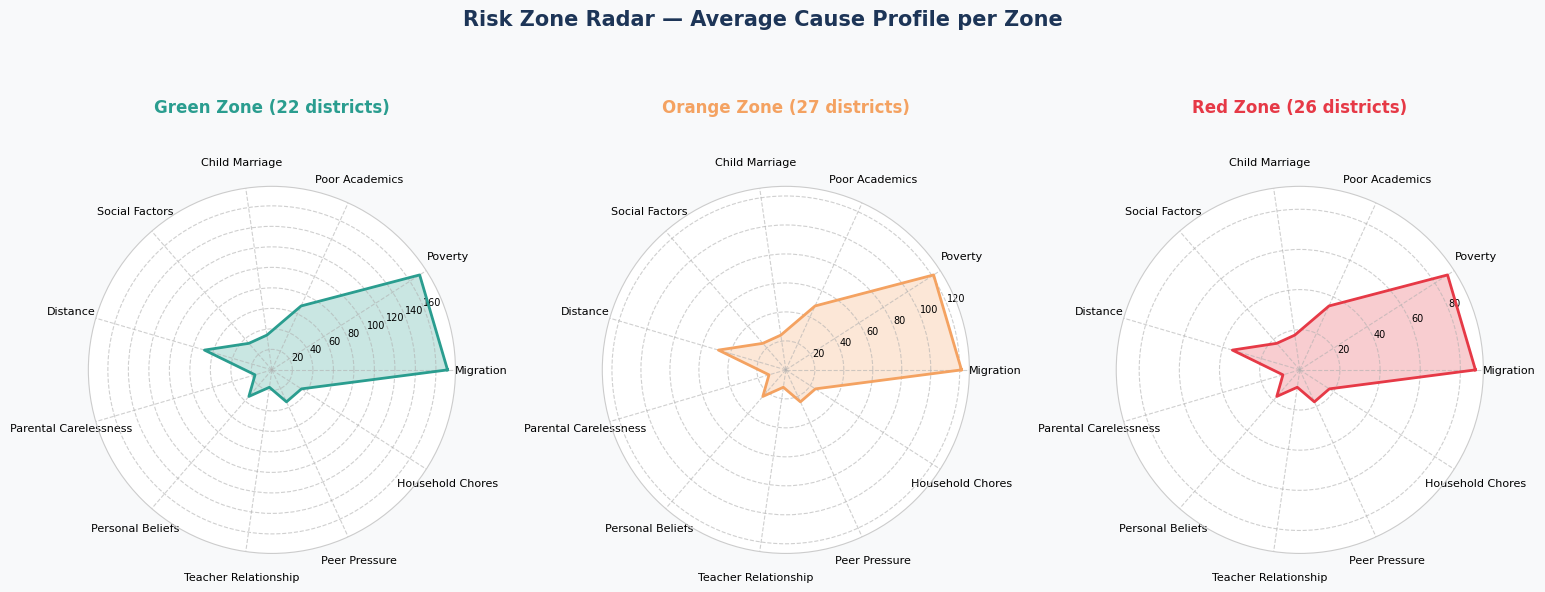

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Categories
cats = CAUSE_LABELS
N = len(cats)

# Compute angles for radar chart
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

# Create figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 7),
    subplot_kw=dict(polar=True)
)

# Main title
fig.suptitle(
    'Risk Zone Radar — Average Cause Profile per Zone',
    **TITLE_KW
)

# Plot radar chart for each risk zone
for ax, (zone, col) in zip(axes, ZONE_COLORS.items()):
    sub = df[df['Risk_Zone'] == zone]

    # Average values for each cause
    vals = [sub[c].mean() for c in CAUSE_COLS]
    vals += vals[:1]

    # Plot
    ax.plot(angles, vals, color=col, linewidth=2)
    ax.fill(angles, vals, color=col, alpha=0.25)

    # Category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=8)

    # Move subplot title higher
    ax.set_title(
        f'{zone} Zone ({len(sub)} districts)',
        fontsize=12,
        fontweight='bold',
        color=col,
        y=1.18
    )

    # Style
    ax.tick_params(axis='x', labelsize=8, pad=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['polar'].set_color('#cccccc')

# Increase spacing between plots and leave room for titles
fig.subplots_adjust(top=0.82, wspace=0.40)

plt.show()